# Chapter 08 이미지를 위한 인공 신경망
## 08-1 합성곱 신경망의 구성 요소
### 합성곱
* **합성곱convolution**은 마치 입력 데이터에 마법의 도장을 찍어서 유용한 특성만 드러나게 하는 것으로 비유할 수 있음.
* 인공 신경망은 처음에 가중치 $w_{1}$ ~ $w_{10}$과 절편 $b$를 랜덤하게 초기화한 다음 에포크를 반복하면서 경사 하강법 알고리즘을 사용하여 손실이 낮아지도록 최적의 가중치와 절편을 찾아감. 이것이 바로 모델 훈련.
* 예를 들어 밀집층에 뉴런이 3개 있다면 출력은 3개. 입력 개수에 상관없이 동일.
* 합성곱은 밀집층의 계산과 조금 다름. 입력 데이터 전체에 가중치를 적용하는 것이 아니라 일부에 가중치를 곱함.
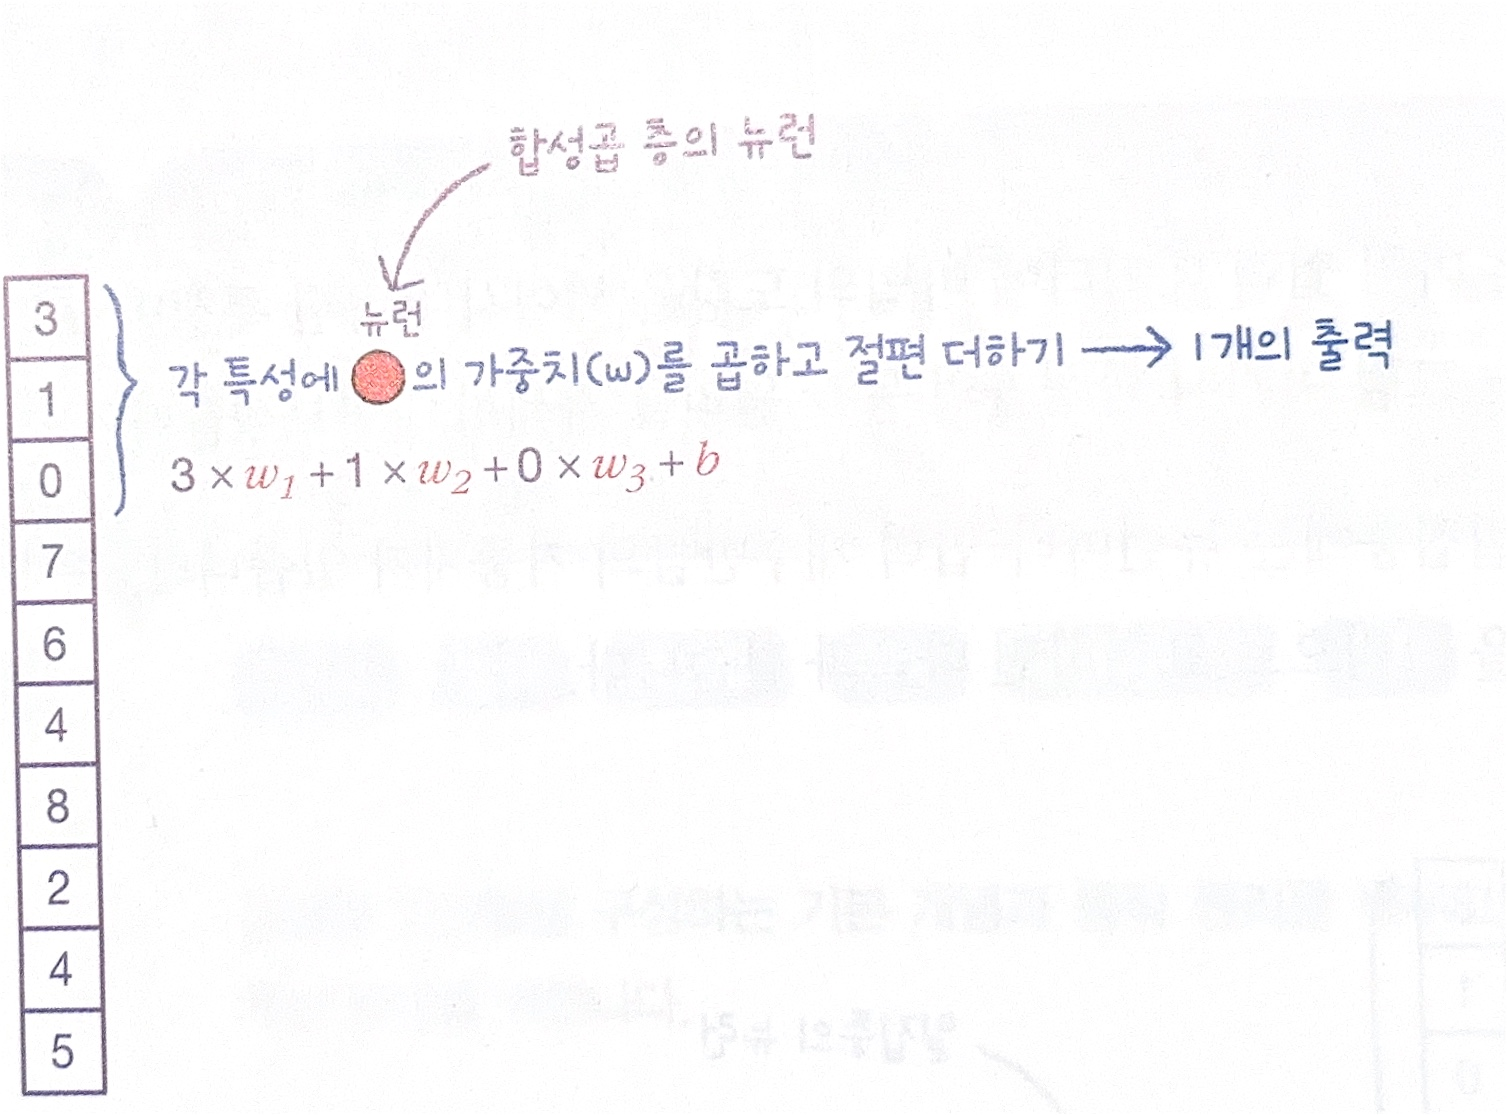
* 가중치 $w_{1}$~$w_{3}$이 입력의 처음 3개 특성과 곱해져 1개의 출력을 만듦. 그다음이 중요. 이 뉴런이 한 칸 아래로 이동해 두 번째부터 네 번째 특성과 곱해져 새로운 출력을 만듦.
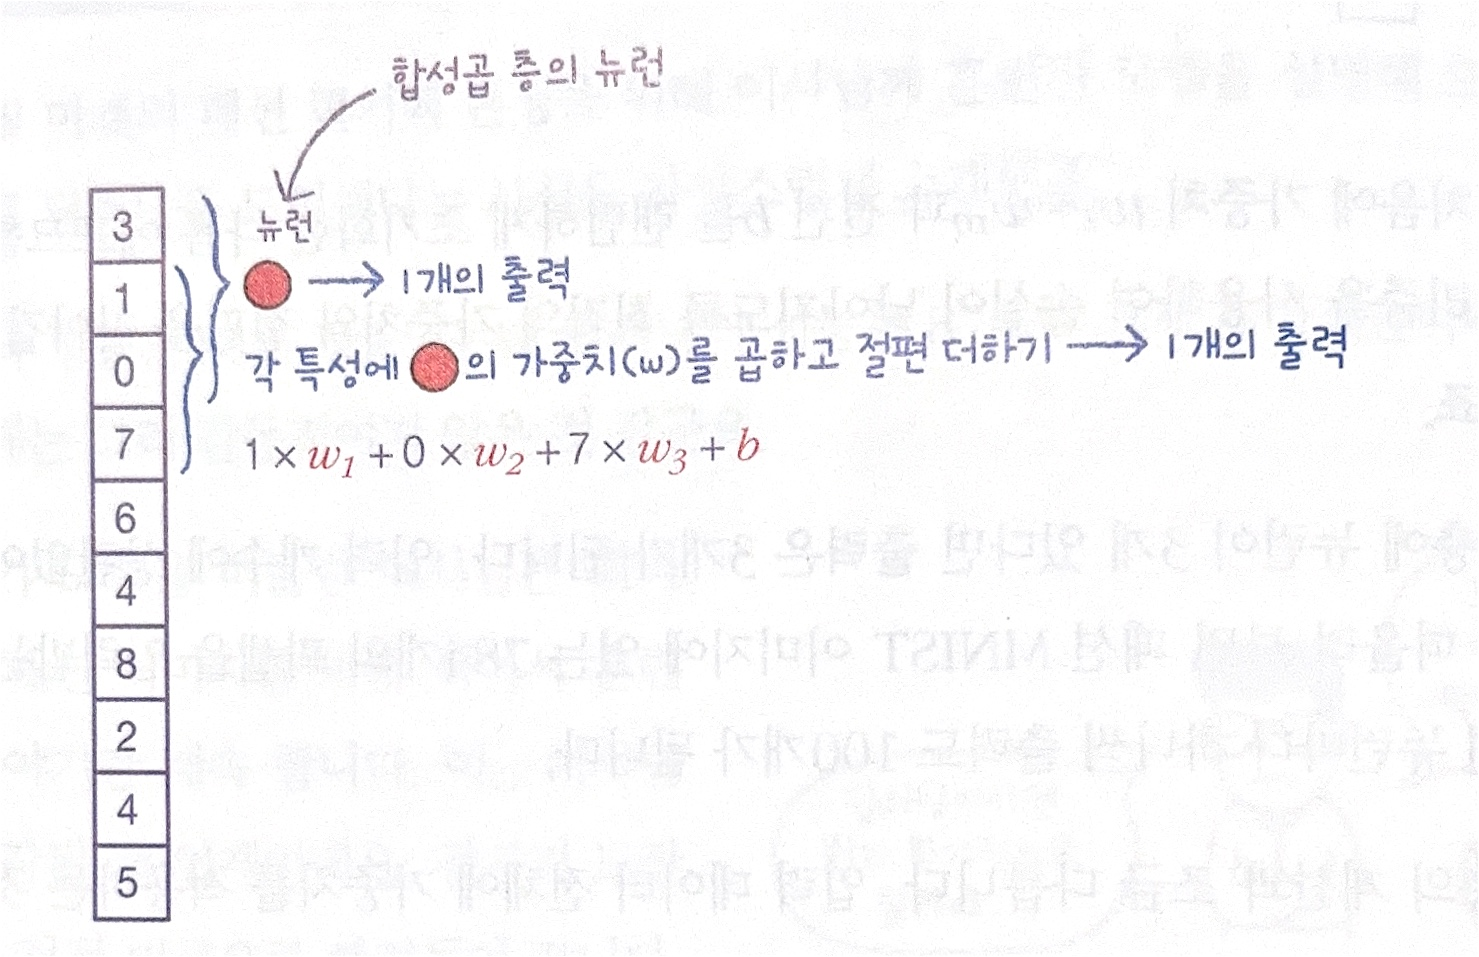
* 여기에서 중요한 것은 첫 번째 합성곱에 사용된 가중치 $w_{1}$~$w_{3}$과 절편 $b$가 두 번째 합성곱에도 동일하게 사용됨. 이렇게 한 칸씩 아래로 이동하면서 출력을 만드는 것이 합성곱.
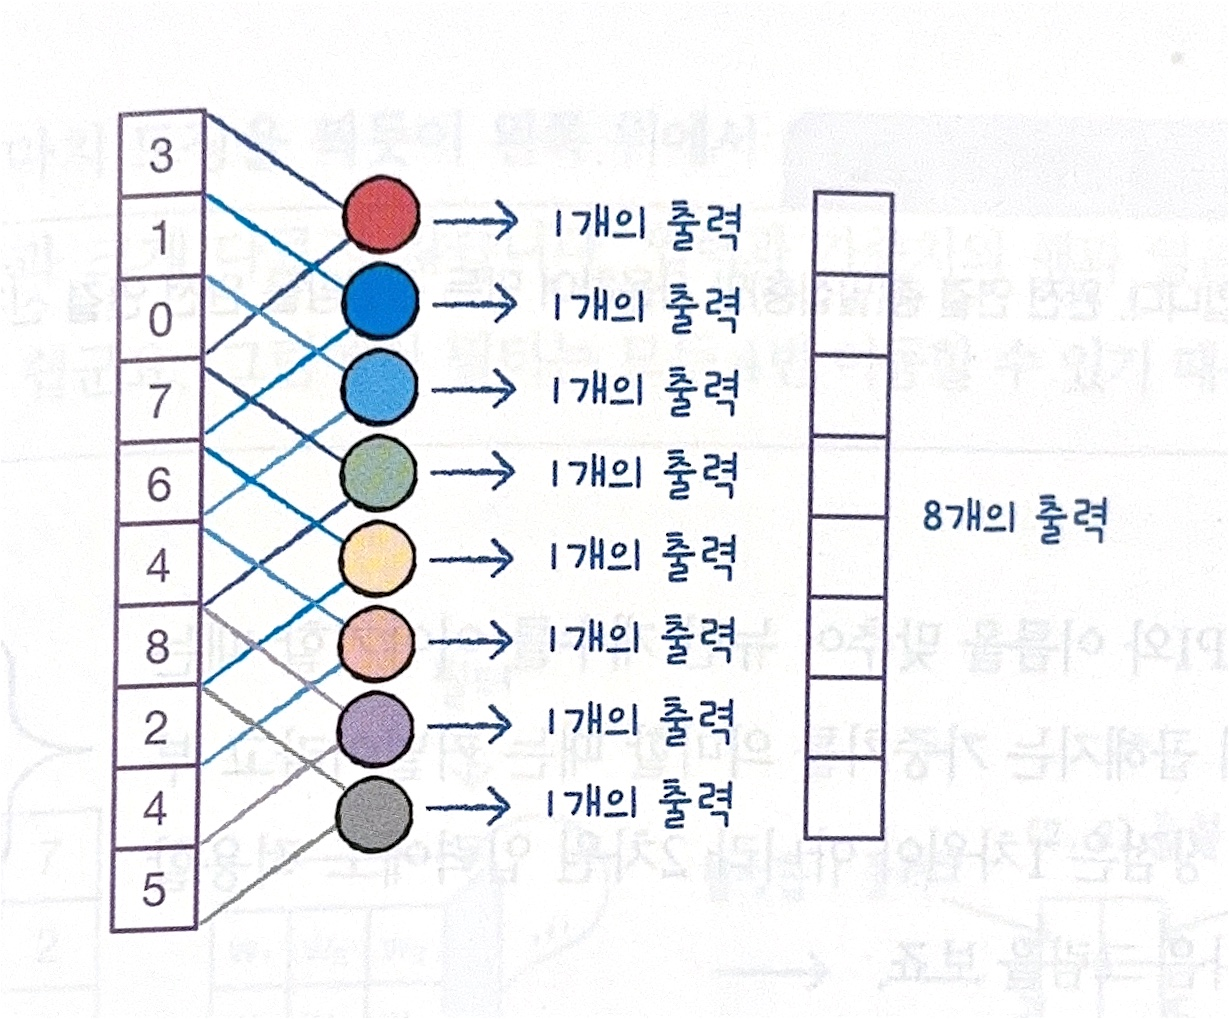
* 쉽게 구분할 수 있도록 8번의 계산을 다른 색으로 나타냈지만 모두 같은 뉴런. 즉 모두 같은 가중치 $w_{1}$~$w_{3}$과 절편 $b$를 사용.
* 밀집층의 뉴런은 입력 개수만큼 10개의 가중치를 가지고 1개의 출력을 만듦. 합성곱 층의 뉴런은 3개의 가중치를 가지고 8개의 출력을 만듦.
* 합성곱 층의 뉴런에 있는 가중치 개수는 정하기 나름. 즉 또 다른 하이퍼파라미터. 이는 마치 입력 데이터 위를 이동하면서 같은 도장으로 하나씩 찍는 것처럼 생각할 수 있음.
* 이전에 그렸던 신경망 층의 그림은 뉴런이 길게 늘어서 있고 서로 조밀하게 연결되어 있음. 그런데 합성곱에서는 뉴런이 입력 위를 이동하면서 출력을 만들기 때문에 이런 식으로 표현하기가 어려움. 또 뉴런이라고 부르기도 어색. -> **합성곱 신경망convolutional neural network, CNN**에서는 완전 연결 신경망과 달리 뉴런을 **필터filter**라고 부름. 혹은 **커널kernel**

> 완전 연결 신경망이 뭐죠?
> * 7장에서 만들었던 신경망. 완전 연결 층(밀집층)만 사용하여 만든 신경망을 완전 연결 신경망(밀집 신경망)이라고 부름.

* 입력이 2차원 배열이면 필터도 2차원이어야 함.
* 왼쪽 위 모서리에서부터 합성곱을 시작. 입력의 9개 원소와 커널의 9개 가중치를 곱한 후 (물론 여기에서도 절편을 더함) 1개의 출력을 만듦.
* 그다음에는 필터가 오른쪽으로 한 칸 이동하여 합성곱을 또 수행. 더 이상 오른쪽으로 한 칸 이동할 수 없을 때는 아래로 한 칸 이동한 다음 다시 왼쪽에서부터 합성곱을 수행. 그리고 다시 오른쪽으로 한 칸 이동.
* 합성곱은 마치 도장을 찍듯이 왼쪽 위에서 오른쪽 맨 아래까지 이동하면서 출력을 만듦. 계산식은 밀집층과 크게 다르지 않음. 입력과 가중치의 행과 열을 맞추어 곱셈하고 모두 더하는 게 전부.
* 이때 4개의 출력을 필터가 입력에 놓인 위치에 맞게 2차원으로 배치. 즉 왼쪽 위, 오른쪽 위, 왼쪽 아래, 오른쪽 아래 모두 4개의 위치에 해당 값을 놓음. 이렇게 출력을 2차원으로 표현하면 (4,4) 크기의 입력을 (2,2) 크기로 압축한 느낌이 남. 합성곱 계산을 통해 얻은 출력을 특별히 **특성 맵feature map**이라고 부름.

> 필터, 커널, 특성 맵 같은 새로운 용어를 모두 알아야 하나요?
> * 이런 용어는 이 책뿐만 아니라 공통으로 사용하는 용어. 이미 이 분야의 많은 개발자나 학자가 사용하는 용어인 만큼 익숙해져야 다른 사람과 원활하게 의견을 나눌 수 있고 다른 책을 볼 때도 쉽게 이해할 수 있음.

* 밀집층에서 여러 개의 뉴런을 사용하듯이 합성곱 층에서도 여러 개의 필터를 사용. 하나만 사용할 이유는 없음.
* 밀집층에 있는 뉴런의 가중치가 모두 다르듯이 합성곱 층에 있는 필터의 가중치(커널)도 모두 다름. 너무 당연하지만 같은 가중치를 가진 필터를 여러 개 사용할 이유가 없음.
* 실제 계산은 밀집층과 동일하게 단순히 입력과 가중치를 곱하는 것이지만 2차원 형태를 유지하는 점이 다름. 또 입력보다 훨씬 작은 크기의 커널을 사용하고 입력 위를 (왼쪽에서 오른쪽으로, 위에서 아래로) 이동하면서 2차원 특성 맵을 만듦. 이렇게 2차원 구조를 그대로 사용하기 때문에 합성곱 신경망이 이미지 처리 분야에서 뛰어난 성능을 발휘.

### 케라스 합성곱 층


```
from tensorflow import keras
keras.layers.Conv2D(10, kernel_size=(3, 3), activation='relu')
```

* Conv2D 클래스의 첫 번째 매개변수는 필터의 개수.
* kernel_size 매개변수는 필터에 사용할 커널의 크기를 지정.
* 필터의 개수와 커널의 크기는 반드시 지정해야 하는 매개변수.
* 마지막으로 밀집층에서처럼 활성화 함수를 지정. 여기서는 렐루 함수를 선택.

> 그럼 특성 맵은 활성화 함수를 적용하기 전인가요? 후인가요?
> * 결론부터 이야기하자면 후. 완전 연결 신경망에서처럼 합성곱 신경망에서도 종종 활성화 함수를 언급하지 않음. 일반적으로 특성 맵은 활성화 함수를 통과한 값을 나타냄. 합성곱에서는 활성화 출력이란 표현을 잘 쓰지 않음. 혼동하지 말 것.

> 커널의 크기는 어떻게 정하나요?
> * 앞에서 잠깐 언급했지만 커널의 크기는 하이퍼파라미터. 따라서 여러 가지 값을 시도해 봐야 함. 하지만 보통 (3, 3)이나 (5, 5) 크기가 권장됨.

* 합성곱 신경망의 정의? -> 일반적으로 1개 이상의 합성곱 층을 쓴 인공 신경망을 **합성곱 신경망**이라고 부름. 즉 꼭 합성곱 층만 사용한 신경망을 합성곱 신경망이라고 부르는 것은 아님. 이전 장에서 보았듯이 클래스에 대한 확률을 계산하려면 마지막 층에 클래스 개수만큼의 뉴런을 가진 밀집층을 두는 것이 일반적이므로.
#### 패딩과 스트라이드
* 앞에서 예로 들었던 합성곱 계산은 (4, 4) 크기의 입력에 (3, 3) 크기의 커널을 적용하여 (2, 2) 크기의 특성 맵을 만들었음. 그런데 만약 커널 크기는 (3, 3)으로 그대로 두고 출력의 크기를 입력과 동일하게 (4, 4)로 만들려면 어떻게 해야 할까?
* (4, 4) 입력과 동일한 크기의 출력을 만들려면 마치 더 큰 입력에 합성곱하는 척해야 함.
* 이렇게 입력 배열의 주위를 가상의 원소로 채우는 것을 **패딩padding**이라고 함. 실제 입력값이 아니기 때문에 패딩은 0으로 채움. 즉 (4, 4) 크기의 입력에 0을 1개 패딩 하면 다음과 같은 (6, 6) 크기의 입력이 됨. 패딩의 역할은 순전히 커널이 도장을 찍을 횟수를 늘려주는 것밖에는 없음. 실제 값은 0으로 채워져 있기 때문에 계산에 영향을 미치지는 않음.
* 이렇게 입력과 특성 맵의 크기를 동일하게 만들기 위해 입력 주위에 0으로 패딩 하는 것을 **세임 패딩same padding**이라고 부름. 합성곱 신경망에서는 세임 패딩이 많이 사용됨.
* 패딩 없이 순수한 입력 배열에서만 합성곱을 하여 특성 맵을 만드는 경우를 **밸리드 패딩valid padding**이라고 함. 밸리드 패딩은 특성 맵의 크기가 줄어들 수밖에 없음.
* 그럼 왜 합성곱에서는 패딩을 즐겨 사용할까? 만약 패딩이 없다면 위의 예에서 (4, 4) 크기의 입력에 패딩 없이 합성곱을 한다면 왼쪽 위 모서리의 3은 커널 도장에 딱 한 번만 찍힘. 사실 네 모서리에 있는 다른 3개의 값도 마찬가지.
* 반면 다른 원소들은 2번 이상 커널과 계산됨. 가운데 있는 4개 원소 4, 8, 5, 1은 4번의 합성곱 계산에 모두 포함됨. 만약 이 입력을 이미지라고 생각하면 모서리에 있는 중요한 정보가 특성 맵으로 잘 전달되지 않을 가능성이 높음. 반면 가운데 있는 정보는 두드러지게 표현됨.
* 적절한 패딩은 이처럼 이미지의 주변에 있는 정보를 잃어버리지 않도록 도와줌.



```
keras.layers.Conv2D(10, kernel_size=(3,3), activation='relu', padding='same')
```

* 지금까지 본 합성곱 연산은 좌우, 위아래로 한 칸씩 이동. 하지만 두 칸씩 건너뛸 수도 있음. 이렇게 두 칸씩 이동하면 만들어지는 특성 맵의 크기는 더 작아짐. 커널 도장을 찍는 횟수가 줄어드니까! -> 이런 이동의 크기를 **스트라이드stride**라고 함. 기본으로 스트라이드는 1.


```
keras.layers.Conv2D(10, kernel_size=(3,3), activation='relu', padding='same', strides=1)
```

* strides 매개변수는 오른쪽으로 이동하는 크기와 아래쪽으로 이동하는 크기를 (1, 1)과 같이 튜플을 사용해 각각 지정할 수 있음. 하지만 커널의 이동 크기를 가로세로 방향으로 다르게 지정하는 경우는 거의 없음. 또 1보다 큰 스트라이드를 사용하는 경우도 드묾. 대부분 기본값을 그대로 사용하기 때문에 strides 매개변수는 잘 사용하지 않음.

#### 풀링
* **풀링pulling**은 합성곱 층에서 만든 특성 맵의 가로세로 크기를 줄이는 역할을 수행. 하지만 특성 맵의 개수는 줄이지 않음. 예를 들면 다음 그림처럼 (2, 2, 3) 크기의 특성 맵에 풀링을 적용하면 마지막 차원인 개수는 그대로 유지하고 너비와 높이만 줄어들어 (1, 1, 3) 크기의 특성 맵이 됨.
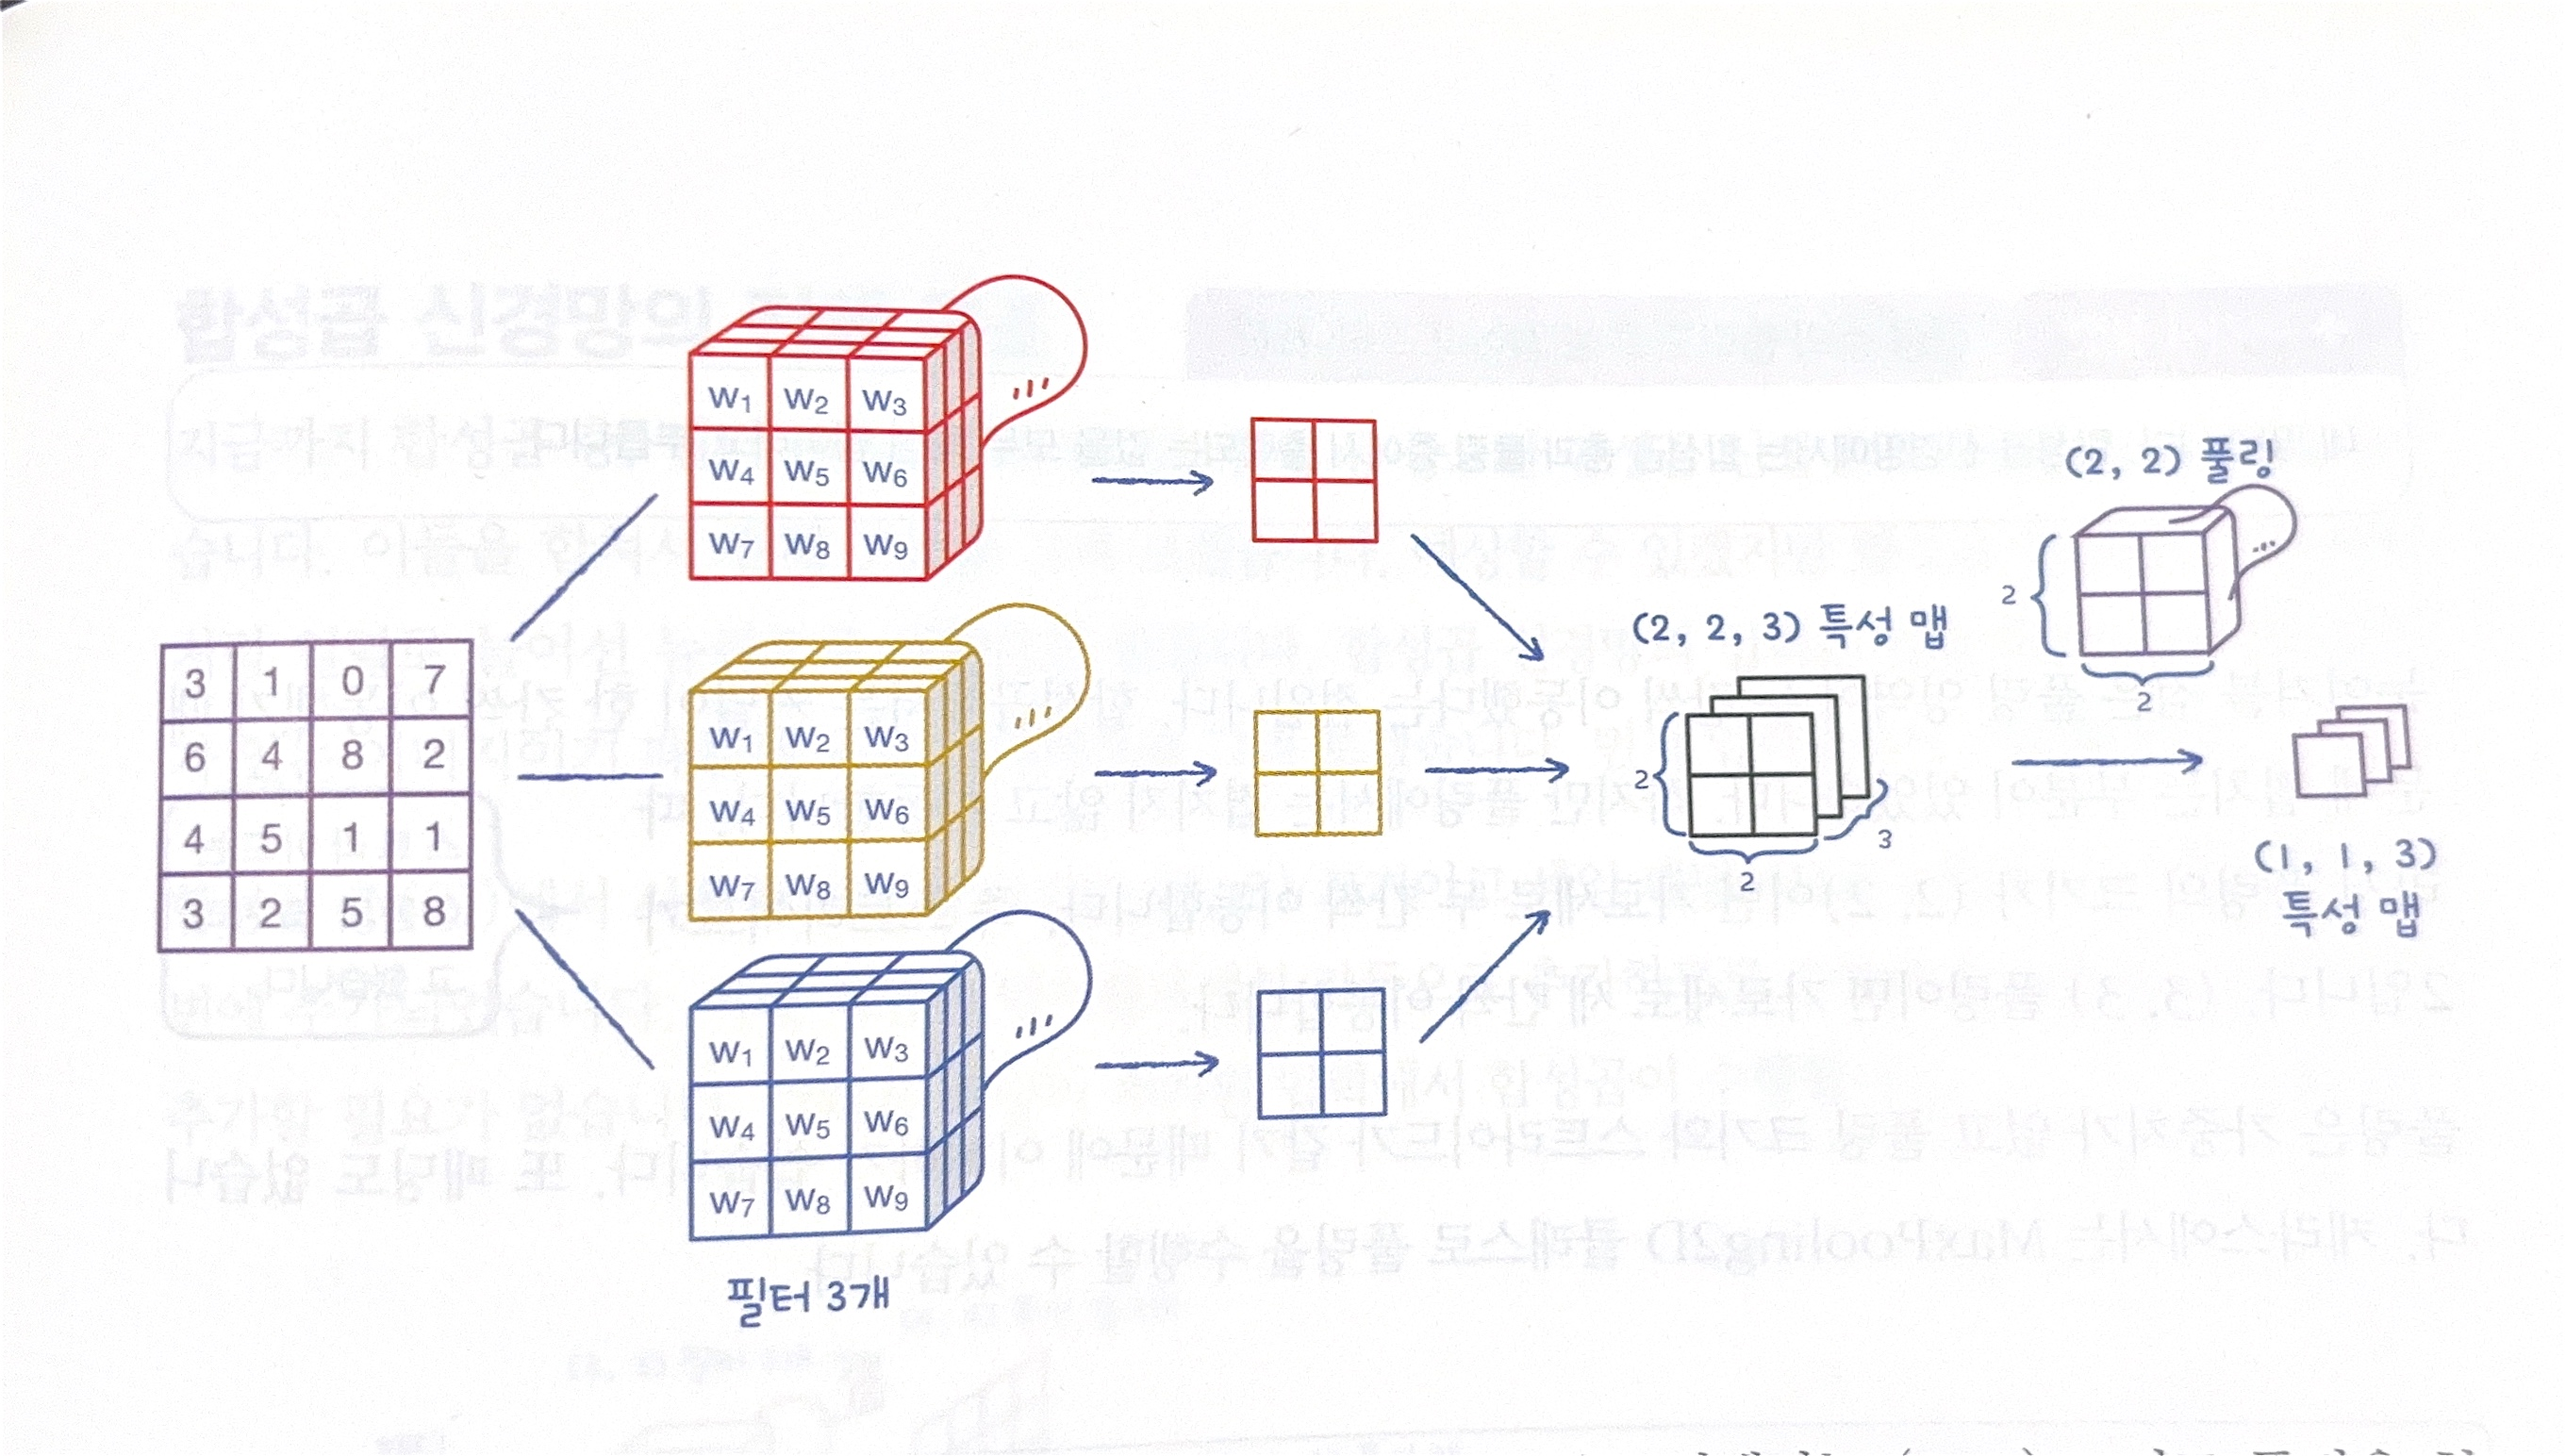
* 풀링도 합성곱처럼 입력 위를 지나가면서 도장을 찍음. 위 그림에서는 (2, 2) 크기로 풀링을 함. 하지만 풀링에는 가중치가 없음. 도장을 찍은 영역에서 가장 큰 값을 고르거나 평균값을 계산. 이를 각각 **최대 풀링max pooling**과 **평균 풀링averate pooling**이라고 부름. 풀링은 합성곱 층과 뚜렷이 구분되기 때문에 풀링 층이라고 부르겠음.
* 가령 (4, 4) 크기의 특성 맵이 있다고 가정해 보겠음. 여기에 (2, 2) 최대 풀링을 적용하면 절반으로 크기가 줄어듦.
* 최대 풀링은 가장 큰 값을 고르기 때문에 첫 번째 (2, 2) 영역에서 9를 고르고 그다음 7, 8, 6을 차례대로 골라 (2, 2) 크기의 출력을 만듦. 특성 맵이 여러 개라면 동일한 작업을 반복. 즉 10개의 특성 맵이 있다면 풀링을 거친 특성 맵도 10개가 됨.

> 풀링 층의 출력도 특성 맵이라고 하나요?
> * 맞음. 합성곱 신경망에서는 합성곱 층과 풀링 층에서 출력되는 값을 모두 특성 맵이라고 부름.
* 합성곱에서는 커널이 한 칸씩 이동했기 때문에 겹치는 부분이 있었음. 하지만 풀링에서는 겹치지 않고 이동. -> 풀링의 크기가 (2, 2)이면 가로세로 두 칸씩 이동. 즉 스트라이드가 2.
* 풀링은 가중치가 없고 풀링 크기와 스트라이드 같기 때문에 이해하기  쉬움. 또 패딩도 없음.

```
keras.layers.MaxPooling2D(2)
```

* 가로세로 방향의 풀링 크기를 다르게 하려면 첫 번째 매개변수를 정수의 튜플로 지정할 수 있음.(예를 들면 (2, 3)). 하지만 이런 경우는 극히 드묾.
* 합성곱 층과 마찬가지로 strides와 padding 매개변수는 제공. strides의 기본값은 자동으로 풀링의 크기이므로 따로 지정할 필요가 없음. padding의 기본값은 'valid'로 패딩을 하지 않음. 앞서 언급한 대로 풀링은 패딩을 하지 않기 때문에 이 매개변수를 바꾸는 경우는 거의 없음.
* 꼭 기억할 점은 풀링은 가로세로 방향으로만 진행함. 특성 맵의 개수는 변하지 않고 그대로.

### 합성곱 신경망의 전체 구조
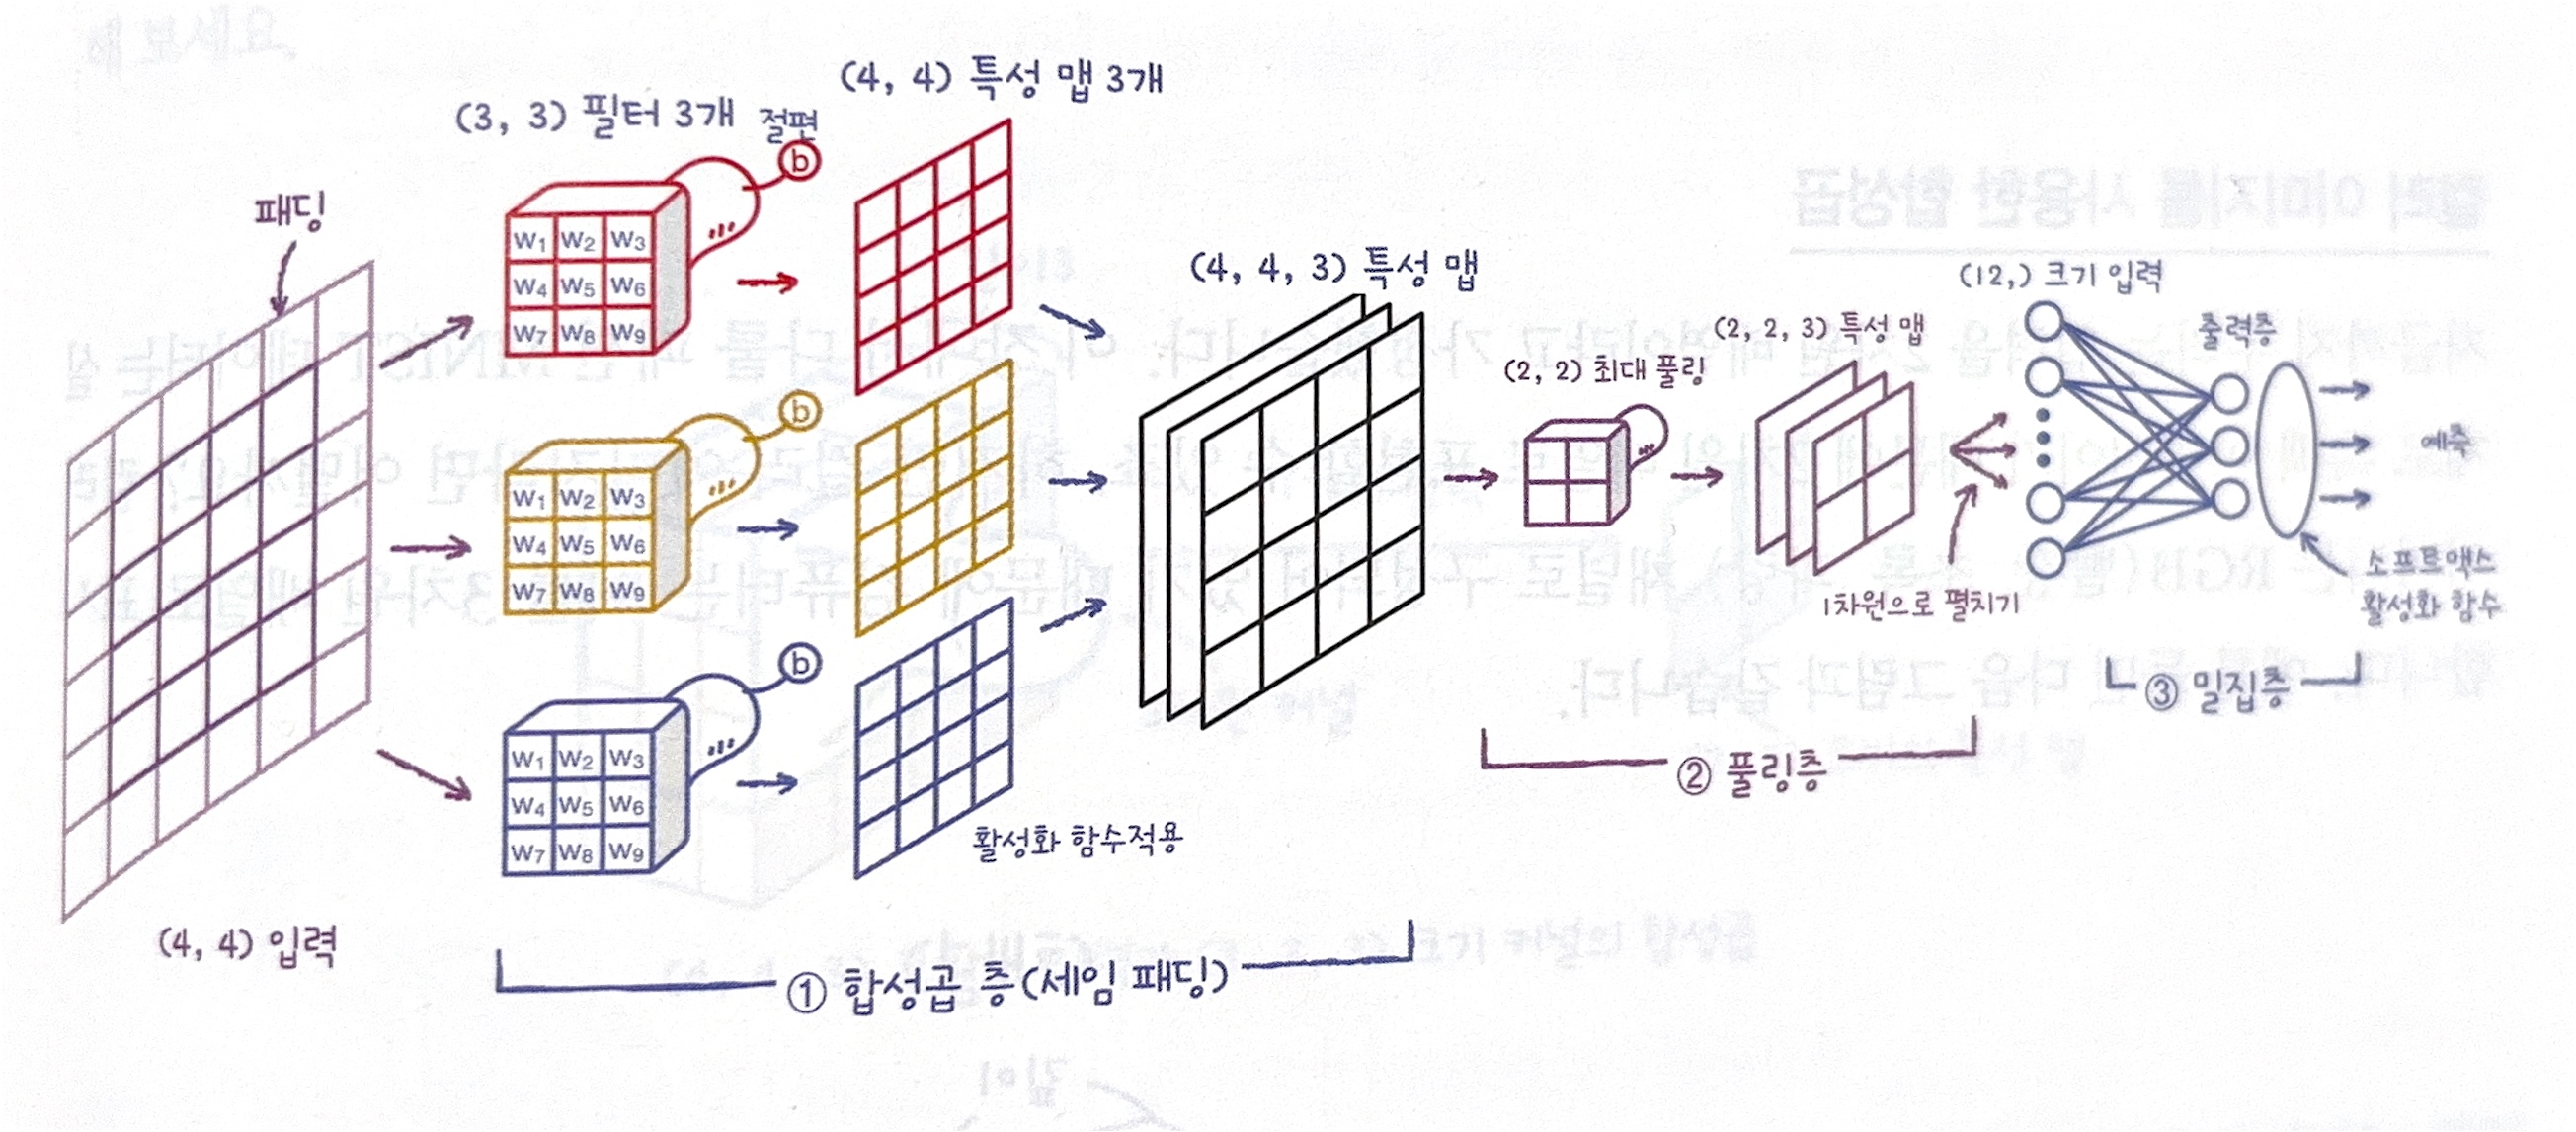
* 풀링을 사용하는 이유는 합성곱에서 스트라이드를 크게 하여 특성 맵을 줄이는 것보다 풀링 층에서 크기를 줄이는 것이 경험적으로 더 나은 성능을 내기 때문. 합성곱 신경망은 이렇게 합성곱 층에서 특성 맵을 생성하고 풀링에서 크기를 줄이는 구조가 쌍을 이룸.
* 출력층에는 3개의 뉴런을 두었음. 즉 3개의 클래스를 분류하는 다중 분류 문제. 출력층에서 계산도니 값은 소프트맥스 활성화 함수를 거쳐 최종 예측 확률이 됨.
#### 컬러 이미지를 사용한 합성곱
* 컬러 이미지는 RGB(빨강, 초록, 파랑) 채널로 구성되어 있기 때문에 컴퓨터는 이를 3차원 배열로 표시.
* 하나의 컬러 이미지는 너비와 높이 차원 외에 깊이 차원(또는 채널 차원)이 있음.
* 깊이가 있는 입력에서 합성곱을 수행하기 위해서는 도장도 깊이가 필요. 즉 필터의 커널 크기가 (3, 3)이 아니라 (3, 3, 3)이 됨.
* 기본적으로 2차원 합성곱과 같지만 도장이 입력의 깊이만큼 쑥 들어간다고 생각해 볼것.
* 여기서 중요한 것은 입력이나 필터의 차원이 몇 개인지 상관없이 항상 출력은 하나의 값이라는 점. 즉 특성 맵에 있는 한 원소가 채워짐.
* 사실 케라스의 합성곱 층은 항상 이렇게 3차원 입력을 기대함. 만약 패션 MNIST 데이터처럼 흑백 이미지일 경우에는 깊이 차원이 1인 3차원 배열로 변환하여 전달.
* 예를 들어 (28, 28) 크기의 2차원 배열을 (28, 28, 1) 크기의 3차원 배열로 변환. 원소 개수는 동일하면서 차원만 맞춘 것.
* 이와 비슷한 경우가 또 있음. 합성곱 층-풀링 층 다음에 다시 또 합성곱 층이 올 때. 에를 들어 첫 번째 합성곱 층의 필터 개수가 5개라고 가정하여 첫 번째 풀링 층을 통과한 특성 맵의 크기가 (4, 4, 5)라고 해 봄.
* 두 번째 합성곱 층에서 필터의 너비와 높이가 각각 3이라면 이 필터의 커널 크기는 (3, 3, 5). 왜냐하면 입력의 깊이와 필터의 깊이는 같아야 하기 때문.
* 두 번째 합성곱 층의 필터 개수가 10개라면 만들어진 특성 맵의 크기는 (2, 2, 10)이 될 것. 이렇게 합성곱 신경망은 너비와 높이는 점점 줄어들고 깊이는 점점 깊어지는 것이 특징. 그리고 마지막에 출력층 전에 특성 맵을 모두 펼쳐서 밀집층의 입력으로 사용.
* 합성곱 신경망에서 필터는 이미지에 있는 어떤 특징을 찾는다고 생각할 수 있음. 처음에는 간단한 기본적인 특징(직선, 곡선 등)을 찾고 층이 깊어질수록 다양하고 구체적인 특징을 감지할 수 있도록 필터의 개수를 늘림. 또 어떤 특징이 이미지의 어느 위치에 놓이더라도 쉽게 감지할 수 있도록 너비와 높이 차원을 점점 줄여가는 것.